# MTSamples — Data Cleaning & Exploratory Data Analysis

**Dataset:** `mtsamples.csv` — a collection of medical transcription sample reports, each tagged with a medical specialty.

**Scope of this notebook:**
- Load the raw data and understand its structure
- Check and handle missing values
- Clean the data (whitespace, empty strings, duplicates, text normalization)
- Explore the cleaned data (EDA): specialty distribution, text-length distributions, keyword patterns
- Export a cleaned CSV for downstream use

**Not covered here (by design):** any model training/modeling. This notebook stops at a clean, well-understood dataset ready for modeling in a separate notebook.


## 1. Setup
Import the libraries needed for loading, cleaning, and visualizing the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


## 2. Load the raw data

In [2]:
df_raw = pd.read_csv('mtsamples.csv')
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)


Shape: 4,999 rows x 6 columns


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


### Column overview

| Column | Description |
|---|---|
| `Unnamed: 0` | Row index carried over from the source CSV (redundant with the DataFrame index) |
| `description` | Short one-line summary of the transcription |
| `medical_specialty` | The medical specialty/category the report belongs to |
| `sample_name` | Title of the specific sample report |
| `transcription` | Full text of the medical transcription |
| `keywords` | Comma-separated keywords/tags for the report |


In [3]:
df_raw.dtypes.to_frame(name='dtype')

,dtype
Unnamed: 0,int64
description,str
medical_specialty,str
sample_name,str
transcription,str
keywords,str


## 3. Missing values check

Two kinds of "missingness" show up in text datasets like this one:
1. **True NaNs** — caught by `isnull()`
2. **Empty / whitespace-only strings** — a row that technically has a value, but it's blank. `isnull()` misses these, so we check for them separately.


In [4]:
missing_counts = df_raw.isnull().sum()
missing_pct = (missing_counts / len(df_raw) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_summary


,missing_count,missing_pct
Unnamed: 0,0,0.00
description,0,0.00
medical_specialty,0,0.00
sample_name,0,0.00
transcription,33,0.66
keywords,1068,21.36


In [5]:
# Empty-string / whitespace-only check (values that are NOT null but are effectively blank)
text_cols = ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
empty_string_counts = {
    col: (df_raw[col].astype(str).str.strip() == '').sum() - df_raw[col].isnull().sum()
    for col in text_cols
}
pd.Series(empty_string_counts, name='blank_but_not_null').to_frame()


,blank_but_not_null
description,6
medical_specialty,0
sample_name,0
transcription,-33
keywords,-987


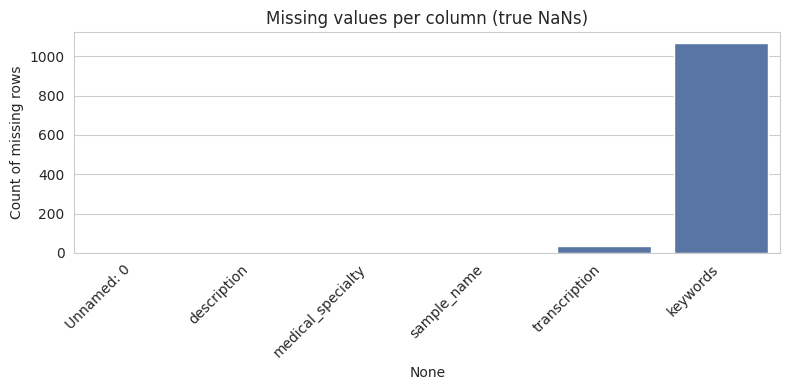

In [6]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_summary.index, y='missing_count', data=missing_summary, color='#4C72B0')
plt.xticks(rotation=45, ha='right')
plt.title('Missing values per column (true NaNs)')
plt.ylabel('Count of missing rows')
plt.tight_layout()
plt.show()


**Findings:**
- `transcription` has a small number of true NaNs (~33 rows, <1% of the data).
- `keywords` has a larger share of true NaNs (~1,068 rows, ~21%) — many reports simply weren't tagged with keywords.
- `description`, `medical_specialty`, and `sample_name` have no true NaNs, but `description` and `keywords` contain a handful of *blank* (empty-string) values that `isnull()` doesn't catch.
- `medical_specialty` values have leading whitespace (e.g. `" Allergy / Immunology"`), which isn't a missing-value issue but does need cleaning (see next section) — otherwise it silently creates duplicate categories.


## 4. Duplicate rows

In [7]:
full_duplicates = df_raw.duplicated().sum()
sample_name_duplicates = df_raw['sample_name'].duplicated().sum()
print(f"Fully duplicated rows: {full_duplicates}")
print(f"Rows with a repeated sample_name: {sample_name_duplicates}")
df_raw['sample_name'].value_counts().head(10).to_frame(name='count')


Fully duplicated rows: 0
Rows with a repeated sample_name: 2622


,count
sample_name,
Lumbar Discogram,5
Hematuria - ER Visit,4
Blood in Urine - ER Visit,4
Adrenalectomy & Umbilical Hernia Repair,4
Ulnar Nerve Transposition,4
Symes Amputation - Hallux,4
Radiofrequency Ablation,4
Neuroplasty,4
Hypergranulation - Consult,4


**Findings:** there are no fully duplicated rows. However, some `sample_name` values repeat (e.g. multiple *"Lumbar Discogram"* reports) — this is expected, since a hospital/clinic can produce several transcriptions of the same type of procedure. These are kept as distinct records since their `transcription` text differs.


## 5. Data cleaning

Steps applied, in order:
1. Drop the redundant `Unnamed: 0` index column.
2. Strip leading/trailing whitespace from all text columns (fixes the `medical_specialty` issue above).
3. Convert blank/whitespace-only strings to proper `NaN` so missingness is consistent and easy to filter on.
4. Drop exact duplicate rows (none found, but kept as a safety step for reproducibility).
5. Reset the index.


In [8]:
df = df_raw.copy()

# 1. Drop redundant index column
df = df.drop(columns=['Unnamed: 0'])

# 2. Strip whitespace on all text columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)  # str() turns real NaNs into the string 'nan'; restore them

# 3. Convert blank strings to NaN
for col in text_cols:
    df[col] = df[col].replace('', np.nan)

# 4. Drop exact duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Dropped {before - after} exact duplicate rows")

# 5. Reset index
df = df.reset_index(drop=True)

print(f"Cleaned shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)


Dropped 0 exact duplicate rows
Cleaned shape: 4,999 rows x 5 columns


,description,medical_specialty,sample_name,transcription,keywords
0,A 23-year-old white female presents with compl...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [9]:
# Confirm the whitespace issue in medical_specialty is fixed
print("Before:", df_raw['medical_specialty'].unique()[:3].tolist())
print("After: ", df['medical_specialty'].unique()[:3].tolist())
print()
print("Unique specialties:", df['medical_specialty'].nunique())


Before: [' Allergy / Immunology', ' Bariatrics', ' Cardiovascular / Pulmonary']
After:  ['Allergy / Immunology', 'Bariatrics', 'Cardiovascular / Pulmonary']

Unique specialties: 40


In [10]:
# Re-check missing values after cleaning
df.isnull().sum().to_frame(name='missing_count')


,missing_count
description,6
medical_specialty,0
sample_name,0
transcription,33
keywords,1149


**Note on remaining missing values:** `transcription` (~33 rows) and `keywords` (~21% of rows) still have genuine missing values after cleaning. These are left as `NaN` rather than dropped or imputed here — how to handle them (drop, impute, or leave as-is) depends on the downstream task, which is out of scope for this notebook. A `keywords`-derived feature, for instance, would simply need to handle nulls; a `transcription`-based NLP task would likely drop the ~33 rows with no text.


## 6. Exploratory Data Analysis

### 6.1 Medical specialty distribution


In [11]:
specialty_counts = df['medical_specialty'].value_counts()
print(f"Number of distinct specialties: {specialty_counts.shape[0]}")
specialty_counts.to_frame(name='count')


Number of distinct specialties: 40


,count
medical_specialty,
Surgery,1103
Consult - History and Phy.,516
Cardiovascular / Pulmonary,372
Orthopedic,355
Radiology,273
General Medicine,259
Gastroenterology,230
Neurology,223
SOAP / Chart / Progress Notes,166


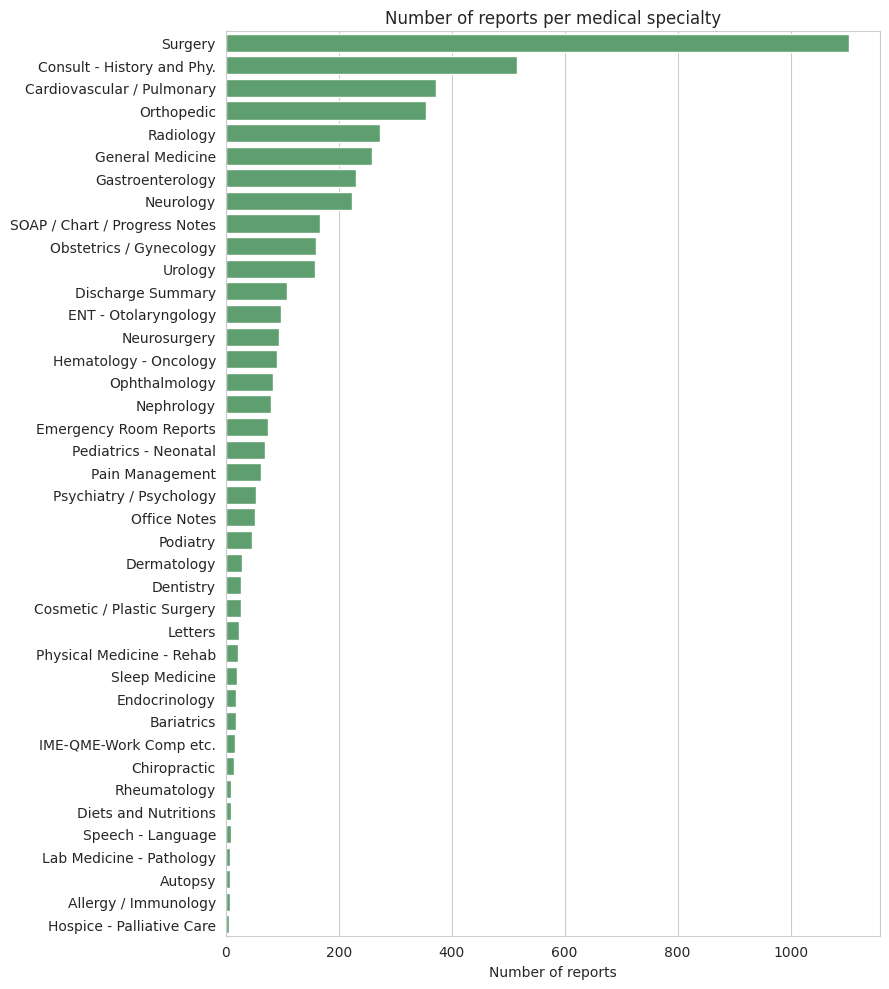

In [12]:
plt.figure(figsize=(9, 10))
sns.barplot(x=specialty_counts.values, y=specialty_counts.index, color='#55A868')
plt.title('Number of reports per medical specialty')
plt.xlabel('Number of reports')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Findings:** the dataset is heavily imbalanced across specialties. `Surgery` (1,103 reports) and `Consult - History and Phy.` (516) dominate, while many specialties (e.g. `Hospice - Palliative Care`, `Allergy / Immunology`, `Autopsy`) have fewer than 10 reports. Any downstream classification task will need to account for this imbalance.


### 6.2 Text length analysis

In [13]:
df['description_length'] = df['description'].str.len()
df['transcription_length'] = df['transcription'].str.len()
df['transcription_word_count'] = df['transcription'].str.split().str.len()

df[['description_length', 'transcription_length', 'transcription_word_count']].describe()


,description_length,transcription_length,transcription_word_count
count,4993.000000,4966.000000,4966.000000
mean,131.429201,3052.308699,465.448852
std,80.201041,1994.076864,316.386344
min,14.000000,11.000000,1.000000
25%,67.000000,1608.000000,241.000000
50%,116.000000,2667.000000,398.000000
75%,180.000000,4011.000000,615.000000
max,491.000000,18425.000000,3029.000000


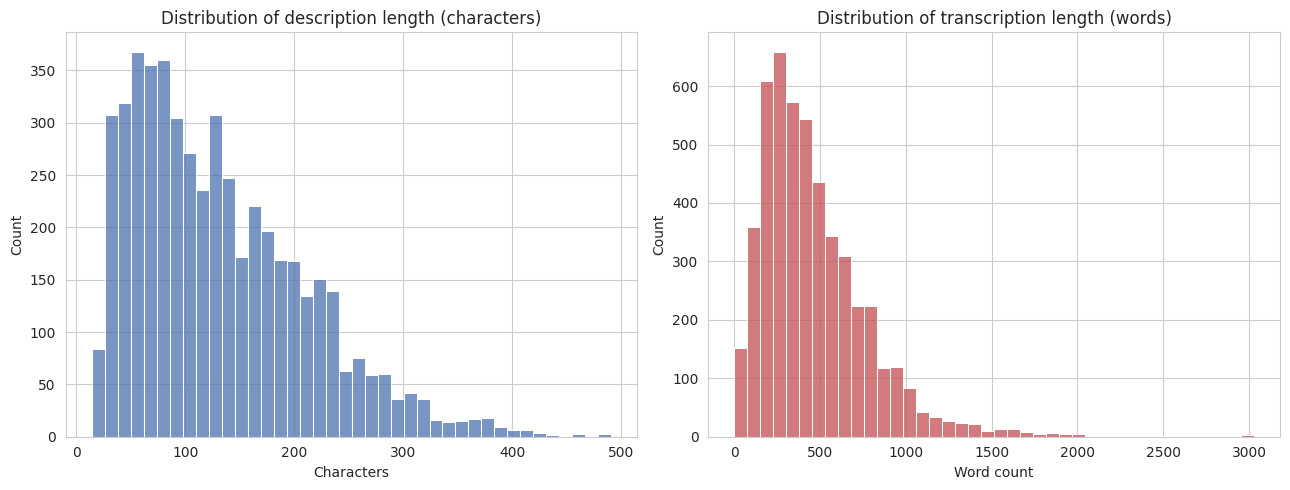

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df['description_length'].dropna(), bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Distribution of description length (characters)')
axes[0].set_xlabel('Characters')

sns.histplot(df['transcription_word_count'].dropna(), bins=40, ax=axes[1], color='#C44E52')
axes[1].set_title('Distribution of transcription length (words)')
axes[1].set_xlabel('Word count')

plt.tight_layout()
plt.show()


**Findings:** `description` fields are short (median ~117 characters, roughly one sentence). `transcription` fields are much longer full-text reports, with a right-skewed distribution — most reports are a few hundred words, but some run over 2,000 words.


### 6.3 Does report length vary by specialty?

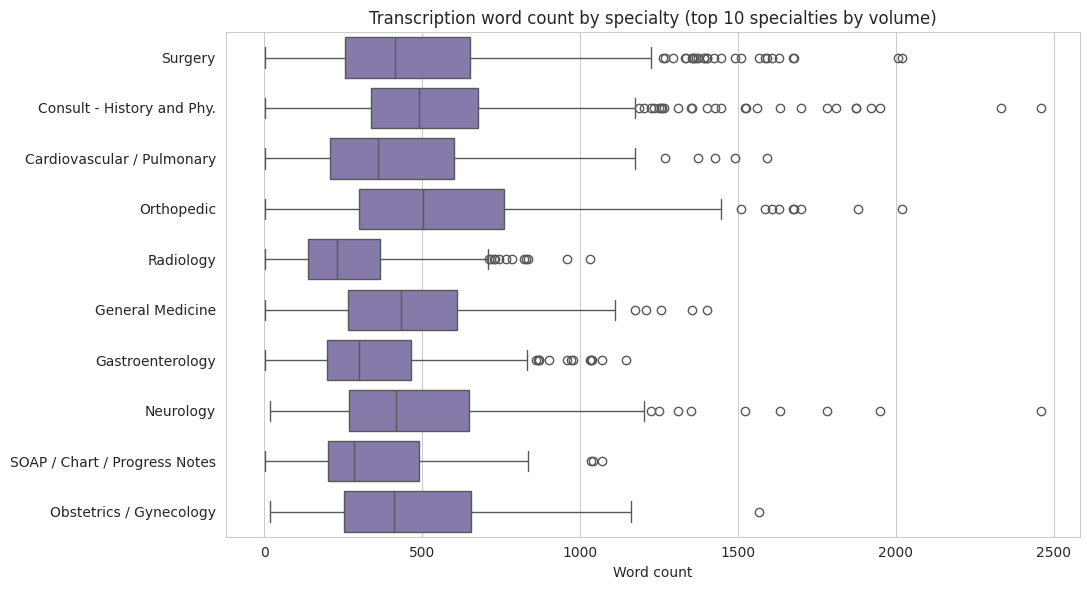

In [15]:
top_specialties = specialty_counts.head(10).index
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df[df['medical_specialty'].isin(top_specialties)],
    x='transcription_word_count', y='medical_specialty',
    order=top_specialties, color='#8172B2'
)
plt.title('Transcription word count by specialty (top 10 specialties by volume)')
plt.xlabel('Word count')
plt.ylabel('')
plt.tight_layout()
plt.show()


**Findings:** report length varies by specialty — `Radiology` and `SOAP / Chart / Progress Notes` reports tend to be shorter and more consistent in length, while `Surgery` and `Neurology` reports show wider variation and longer upper ranges, consistent with more detailed procedural documentation.


### 6.4 Missing keywords by specialty

In [16]:
keyword_missing_by_specialty = (
    df.groupby('medical_specialty')['keywords']
    .apply(lambda s: s.isnull().mean() * 100)
    .sort_values(ascending=False)
)
keyword_missing_by_specialty.to_frame(name='pct_missing_keywords').head(15)


,pct_missing_keywords
medical_specialty,
Autopsy,100.000000
IME-QME-Work Comp etc.,75.000000
Chiropractic,71.428571
Psychiatry / Psychology,64.150943
Emergency Room Reports,61.333333
Consult - History and Phy.,57.364341
Allergy / Immunology,57.142857
Physical Medicine - Rehab,47.619048
General Medicine,47.104247


**Findings:** missing `keywords` are not evenly spread across specialties — some specialties are tagged far more inconsistently than others. This matters if `keywords` is used as a feature: imputing or dropping it globally could disproportionately affect specific specialties.


### 6.5 Most common keywords (overview)

In [17]:
all_keywords = (
    df['keywords'].dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .str.lower()
)
top_keywords = all_keywords.value_counts().head(20)
top_keywords.to_frame(name='count')


,count
keywords,
,2481
surgery,1043
orthopedic,307
cardiovascular / pulmonary,277
: thesetranscribed medical transcription sample reports and examples are provided by various users andare for reference purpose only. mthelpline does not certify accuracy and quality of sample reports.these transcribed medical transcription sample reports may include some uncommon or unusual formats;this would be due to the preference of the dictating physician. all names and dates have beenchanged (or removed) to keep confidentiality. any resemblance of any type of name or date orplace or anything else to real world is purely incidental.,253
radiology,250
consult - history and phy.,220
gastroenterology,199
neurology,165


/tmp/ipykernel_154/3707802205.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


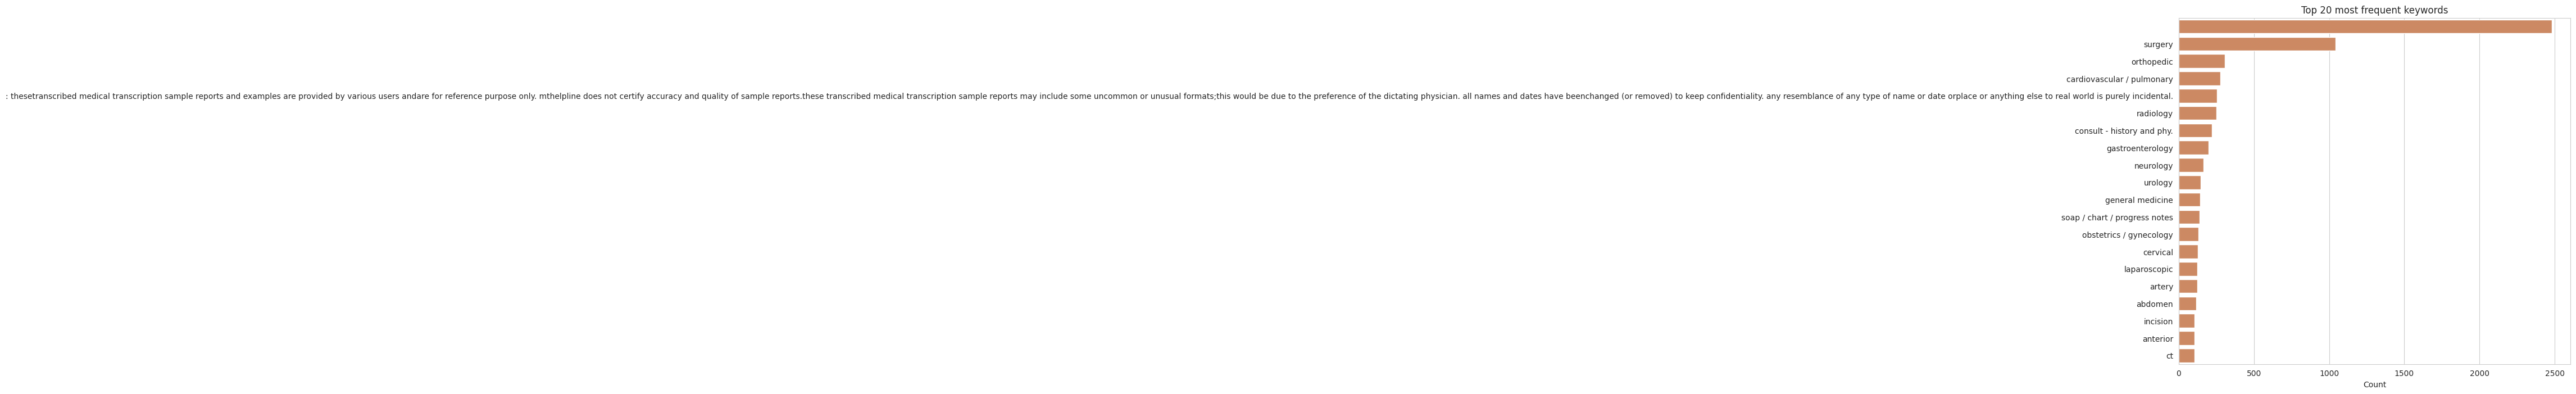

In [18]:
plt.figure(figsize=(9, 8))
sns.barplot(x=top_keywords.values, y=top_keywords.index, color='#DD8452')
plt.title('Top 20 most frequent keywords')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 7. Export the cleaned dataset

Save the cleaned DataFrame (whitespace-stripped, blanks converted to NaN, duplicates dropped, redundant index column removed) so it can be reused directly in a modeling notebook without repeating this cleaning process.


In [19]:
output_cols = ['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']
df[output_cols].to_csv('mtsamples_cleaned.csv', index=False)
print("Saved mtsamples_cleaned.csv")
print(f"Final shape: {df[output_cols].shape[0]:,} rows x {df[output_cols].shape[1]} columns")


Saved mtsamples_cleaned.csv
Final shape: 4,999 rows x 5 columns


## 8. Summary

| Step | Result |
|---|---|
| Raw rows | 4,999 |
| Rows after cleaning | see output above (no rows dropped — no exact duplicates found) |
| Columns dropped | `Unnamed: 0` (redundant index) |
| Whitespace issue fixed | `medical_specialty` had leading spaces on every value |
| True missing values | `transcription` (~33 rows), `keywords` (~1,068 rows) |
| Blank-string issues found & fixed | a few blank `description` and `keywords` values, converted to proper `NaN` |
| Duplicate rows | none |
| Specialties | 40, heavily imbalanced (`Surgery` most common) |
| Report length | `description` short (~1 sentence); `transcription` long-form, right-skewed |

**Next steps (not covered in this notebook):** text preprocessing (tokenization, stopword removal, lemmatization) and model training for tasks such as specialty classification or NER, which should build on `mtsamples_cleaned.csv`.
